# Evaluate RNO Control (Checkpoint)
This notebook loads a saved fine-tuned checkpoint and reruns analyses #17-#20 without retraining.


In [1]:
# 1) Imports and configuration
import os
import time
import random
import numpy as np
import torch
from torch.utils.data import IterableDataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

data_path = "/home/pk222/projects/PDEControl_DPC/datasets/heat_smooth_f_dataset.npz"
samples_to_load = 400
seed = 32
train_frac = 0.8
batch_size = 75
num_steps = 1000
log_iter = 10
lr = 1e-3
transition_steps = 2000
decay_rate = 0.9
sample_id = 5
num_samples_to_evaluate = 10

checkpoint_path = "/home/pk222/projects/tipping-point-forecast/heat/result_rno_32_gaussian_actuators/rno_gaussian_actuators_finetune_seed32_H5_20260228T071100Z.pt"

resume_path = ""
resume_strict = True
save_best = True
save_last = True

# RNO preprocessing hyperparameters
sub = 1
T = 16
n_intervals = 5
train_up_to_tipping_point = False
tipping_data_split_prop = 0.67
debug_preprocessing_shapes = True


This notebook is evaluation-only for control-conditioned RNO models.
It loads a fine-tuned checkpoint and reruns analysis sections #17-#20 without retraining.


In [2]:
# 2) Reproducibility and device
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required but not available.")
device = torch.device("cuda")
print(f"Using device: {device}")


Using device: cuda


In [3]:
# 3) Data loading and RNO preprocessing
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Dataset not found: {data_path}")

dataset = np.load(data_path)
solutions = torch.from_numpy(dataset["solutions"][:samples_to_load]).float()
controls = torch.from_numpy(dataset["controls"][:samples_to_load]).float()
x_cord = torch.from_numpy(dataset["x"]).reshape(-1, 1).float()
dt = float(dataset["dt"])

print(f"Loaded {samples_to_load}/{dataset['solutions'].shape[0]} samples:")
print(f"solutions: {tuple(solutions.shape)}")
print(f"controls: {tuple(controls.shape)}")
print(f"x: {tuple(x_cord.shape)}")
print(f"dt: {dt}")

Loaded 400/3000 samples:
solutions: (400, 401, 100)
controls: (400, 400, 4)
x: (100, 1)
dt: 0.001


In [4]:
def round_down(num, divisor):
    return num - (num % divisor)


def chunk_time_axis(arr, chunk_size):
    # arr shape: (ntraj, nt, nfeat) -> (ntraj, n_chunks, chunk_size, nfeat)
    chunks = torch.split(arr, chunk_size, dim=1)
    return torch.stack(chunks, dim=1)

In [5]:
# 1) Align solution/control time lengths and crop to multiple of T
ntraj = min(solutions.shape[0], controls.shape[0])
nt_shared = min(solutions.shape[1] - 1, controls.shape[1])
nt_usable = round_down(nt_shared, T)

solutions = solutions[:ntraj, :nt_usable, :]
controls = controls[:ntraj, :nt_usable, :]

# 2) Optional spatial subsampling on solution/grid only
solutions = solutions[:, :, ::sub]
x_cord = x_cord[::sub]

# 3) Optional pre-tipping crop
if train_up_to_tipping_point:
    tipping_idx = round_down(int(tipping_data_split_prop * solutions.shape[1]), T)
    solutions = solutions[:, :tipping_idx, :]
    controls = controls[:, :tipping_idx, :]

ntraj, nt, nx = solutions.shape
nf = controls.shape[-1]
n_chunks = nt // T

print(f"After preprocessing:")
print(f"solutions: {tuple(solutions.shape)}")
print(f"controls: {tuple(controls.shape)}")
print(f"x: {tuple(x_cord.shape)}")
print(f"ntraj: {ntraj}, nt: {nt}, nx: {nx}, nf: {nf}, n_chunks: {n_chunks}")


After preprocessing:
solutions: (400, 400, 100)
controls: (400, 400, 4)
x: (100, 1)
ntraj: 400, nt: 400, nx: 100, nf: 4, n_chunks: 25


Train/test split by trajectory (same strategy as ks/RNO_KS.py)

In [6]:
# 4) Train/test split by trajectory (same strategy as ks/RNO_KS.py)
n_train_traj = int(train_frac * ntraj)
n_test_traj = ntraj - n_train_traj

sol_train = solutions[:n_train_traj]
sol_test = solutions[n_train_traj:]
ctrl_train = controls[:n_train_traj]
ctrl_test = controls[n_train_traj:]

In [7]:
print(f"Before chunking:")
print(f"sol_train: {tuple(sol_train.shape)}")
print(f"ctrl_train: {tuple(ctrl_train.shape)}")
print(f"sol_test: {tuple(sol_test.shape)}")
print(f"ctrl_test: {tuple(ctrl_test.shape)}")

Before chunking:
sol_train: (320, 400, 100)
ctrl_train: (320, 400, 4)
sol_test: (80, 400, 100)
ctrl_test: (80, 400, 4)


Chunk with T=16: (400 timesteps)

Raw time: 400
Chunk size: T=16
Number of chunks per trajectory: 400/16 = 25

U_chunks: (B, 25, 16, 100, 1)
F_chunks: (B, 25, 16, 4)

In [8]:
# 5) Chunk both streams (keep state and control separate)
sol_train_chunks = chunk_time_axis(sol_train, T).unsqueeze(
    -1
)  # (n_tr, n_chunks, T, nx, 1)
sol_test_chunks = chunk_time_axis(sol_test, T).unsqueeze(
    -1
)  # (n_te, n_chunks, T, nx, 1)

ctrl_train_chunks = chunk_time_axis(ctrl_train, T).unsqueeze(
    -1
)  # (n_tr, n_chunks, T, nf, 1)
ctrl_test_chunks = chunk_time_axis(ctrl_test, T).unsqueeze(
    -1
)  # (n_te, n_chunks, T, nf, 1)

print("After chunking:")
print(f"sol_train_chunks: {tuple(sol_train_chunks.shape)}")
print(f"ctrl_train_chunks: {tuple(ctrl_train_chunks.shape)}")
print(f"sol_test_chunks: {tuple(sol_test_chunks.shape)}")
print(f"ctrl_test_chunks: {tuple(ctrl_test_chunks.shape)}")


After chunking:
sol_train_chunks: (320, 25, 16, 100, 1)
ctrl_train_chunks: (320, 25, 16, 4, 1)
sol_test_chunks: (80, 25, 16, 100, 1)
ctrl_test_chunks: (80, 25, 16, 4, 1)


Build training samples with a sliding window of `n_intervals=5`:

Input uses 5 consecutive chunks: `[i, i+1, i+2, i+3, i+4]`
Target is next chunk: `[i+5]`

So for the model input:

* `timesteps = 5` (history length in chunk units)
* `spatial_dims = (16, 100)` (chunk-internal time, space)
* That gives input like `(batch, 5, channels, 16, 100)` after permute.

Mini picture for one trajectory:

- chunks: `c0 c1 c2 c3 c4 c5 c6 ... c24`
- sample 1: `input=c0..c4`, `target=c5`
- sample 2: `input=c1..c5`, `target=c6`
etc.

In [9]:
def build_windows(sol_chunks, ctrl_chunks, n_intervals_inner):
    x_state, x_ctrl, y_state = [], [], []
    for traj_sol, traj_ctrl in zip(sol_chunks, ctrl_chunks):
        for i in range(sol_chunks.shape[1] - n_intervals_inner - 1):
            x_state.append(traj_sol[i : i + n_intervals_inner])
            x_ctrl.append(traj_ctrl[i : i + n_intervals_inner])
            y_state.append(traj_sol[i + n_intervals_inner])

    x_state = torch.stack(x_state, dim=0)  # (N, n_intervals, T, nx, 1)
    x_ctrl = torch.stack(x_ctrl, dim=0)  # (N, n_intervals, T, nf, 1)
    y_state = torch.stack(y_state, dim=0)  # (N, T, nx, 1)

    x_state = x_state.permute(0, 1, 4, 2, 3).contiguous()  # (N, n_intervals, 1, T, nx)
    x_ctrl = x_ctrl.permute(0, 1, 4, 2, 3).contiguous()  # (N, n_intervals, 1, T, nf)
    y_state = y_state.permute(0, 3, 1, 2).contiguous()  # (N, 1, T, nx)
    return x_state, x_ctrl, y_state


x_train_state, x_train_ctrl, y_train = build_windows(
    sol_train_chunks, ctrl_train_chunks, n_intervals
)
x_test_state, x_test_ctrl, y_test = build_windows(
    sol_test_chunks, ctrl_test_chunks, n_intervals
)

if debug_preprocessing_shapes:
    print("=== RNO preprocessing debug ===")
    print(f"ntraj={ntraj}, nt={nt}, nx={nx}, nf={nf}, n_chunks={n_chunks}")
    print(f"n_train_traj={n_train_traj}, n_test_traj={n_test_traj}")
    print(f"sol_train_chunks: {tuple(sol_train_chunks.shape)}")
    print(f"ctrl_train_chunks: {tuple(ctrl_train_chunks.shape)}")
    print(f"x_train_state: {tuple(x_train_state.shape)}")
    print(f"x_train_ctrl: {tuple(x_train_ctrl.shape)}")
    print(f"y_train: {tuple(y_train.shape)}")
    print(f"x_test_state: {tuple(x_test_state.shape)}")
    print(f"x_test_ctrl: {tuple(x_test_ctrl.shape)}")
    print(f"y_test: {tuple(y_test.shape)}")
    print("=== End preprocessing debug ===")


=== RNO preprocessing debug ===
ntraj=400, nt=400, nx=100, nf=4, n_chunks=25
n_train_traj=320, n_test_traj=80
sol_train_chunks: (320, 25, 16, 100, 1)
ctrl_train_chunks: (320, 25, 16, 4, 1)
x_train_state: (6080, 5, 1, 16, 100)
x_train_ctrl: (6080, 5, 1, 16, 4)
y_train: (6080, 1, 16, 100)
x_test_state: (1520, 5, 1, 16, 100)
x_test_ctrl: (1520, 5, 1, 16, 4)
y_test: (1520, 1, 16, 100)
=== End preprocessing debug ===


In [10]:
# 4) RNO utilities
import operator
from functools import reduce
from tqdm.auto import tqdm


class LpLoss(object):
    def __init__(self, d=2, p=2, size_average=True, reduction=True):
        assert d > 0 and p > 0
        self.d = d
        self.p = p
        self.reduction = reduction
        self.size_average = size_average

    def rel(self, x, y):
        num_examples = x.size()[0]
        diff_norms = torch.norm(
            x.reshape(num_examples, -1) - y.reshape(num_examples, -1), self.p, 1
        )
        y_norms = torch.norm(y.reshape(num_examples, -1), self.p, 1)
        if self.reduction:
            if self.size_average:
                return torch.mean(diff_norms / y_norms)
            return torch.sum(diff_norms / y_norms)
        return diff_norms / y_norms

    def __call__(self, x, y):
        return self.rel(x, y)


def count_params(model):
    c = 0
    for p in list(model.parameters()):
        c += reduce(operator.mul, list(p.size()), 1)
    return c


In [11]:
# 5a) Gaussian-actuator imports + strategy config
from neuralop.models import RNO

try:
    from rno_functions import RNOControlARGaussianActuators
except ModuleNotFoundError:
    from heat.rno_functions import RNOControlARGaussianActuators

model_input_mode = "gaussian_actuators"
control_dim = int(x_train_ctrl.shape[-1])

GAUSS_MUS = (0.2, 0.4, 0.6, 0.8)
GAUSS_SIGMA = 0.1
GAUSS_X_MIN = 0.0
GAUSS_X_MAX = 1.0
GAUSS_NORMALIZE = True


Function that helps lifts controls $u(t)\in\mathbb{R}^{4}$ to a 1D forcing field $f(x,t)\in\mathbb{R}^{n_x}$ using Gaussian actuator footprints centered at $\mu={0.2,0.4,0.6,0.8}$ with spread $\sigma=0.1$, for $n_x=100$.

The model is
$$
f(x,t)=\sum_{j=1}^{4} u_j(t) \exp\left(-\frac{(x-\mu_j)^2}{2\sigma^2}\right).
$$

`_a_cache_key` is there to make caching correct, not just fast.

`build_rno_input(...)` runs many times (every batch, often every rollout step). Rebuilding `A` each call is wasted work.  
Caching with `_a_cache_key` lets you reuse `A` only when it is an exact match.

It helps because `A` depends on more than one thing:
- `device` (CPU vs GPU)
- `dtype` (`float32`, `float16`, etc.)
- grid size `nx`
- Gaussian settings (`mus`, `sigma`, `x_min`, `x_max`, `normalize`)


In [12]:
# 5d) Gaussian-actuator model + optimizer setup
modes1 = 20
modes2 = 20
width = 28
n_layers = 3
domain_padding = [0.1, 0]

in_channels = 2
out_channels = 1
learning_rate = lr
weight_decay = 1e-4
scheduler_step = 50
scheduler_gamma = 0.5
epochs = 25
save_weights = True

model = RNO(
    n_modes=(modes1, modes2),
    hidden_channels=width,
    in_channels=in_channels,
    out_channels=out_channels,
    n_layers=n_layers,
    domain_padding=domain_padding,
).to(device)

ar_model = RNOControlARGaussianActuators(
    rno=model,
    mus=GAUSS_MUS,
    sigma=GAUSS_SIGMA,
    x_min=GAUSS_X_MIN,
    x_max=GAUSS_X_MAX,
    normalize=GAUSS_NORMALIZE,
).to(device)

print(f"model_input_mode={model_input_mode}")
print(f"control_dim={control_dim}")
print(f"in_channels={in_channels}, out_channels={out_channels}")
print("Model parameters:", count_params(model))

optimizer = torch.optim.Adam(
    model.parameters(), lr=learning_rate, weight_decay=weight_decay
)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=scheduler_step, gamma=scheduler_gamma
)
lploss = LpLoss(size_average=False)


model_input_mode=gaussian_actuators
control_dim=4
in_channels=2, out_channels=1
Model parameters: 3138197


## 12) Multi-step fine-tuning helpers (control-aware)
Control-aware multi-horizon endpoint fine-tuning helper routines, mirroring `train_RNO_state_only.ipynb` behavior.


In [13]:
# 12) Multi-step fine-tuning helpers (control-aware)
# Mirrors train_RNO_state_only.run_multistep_finetuning semantics:
# - mixed horizons h=1..fine_tuning_num_steps
# - endpoint-only loss at each horizon h
# - deterministic horizon-specific loaders
# - scheduler stepped every optimization step

# User-editable multi-step controls
fine_tuning_num_steps = 5
fine_tune_ep = 25
fine_tuning_lr = 1e-3
fine_tune_scheduler_step = 2000
fine_tune_scheduler_gamma = 0.5

# history is the number of most recent history states considered for warm-up + u0.
# Must be <= n_intervals (dataset history length produced in section #5).
multi_step_history = n_intervals
# Warm-up steps before rollout; exclude u0 from warm-up to avoid double use.
multi_step_warmup_steps = multi_step_history - 1

if not isinstance(fine_tuning_num_steps, int) or fine_tuning_num_steps < 1:
    raise ValueError(
        f"fine_tuning_num_steps must be int >= 1, got {fine_tuning_num_steps}"
    )
if (
    not isinstance(multi_step_history, int)
    or multi_step_history < 1
    or multi_step_history > n_intervals
):
    raise ValueError(
        f"multi_step_history must be in [1, n_intervals={n_intervals}], got {multi_step_history}"
    )
if (
    not isinstance(multi_step_warmup_steps, int)
    or multi_step_warmup_steps < 0
    or multi_step_warmup_steps > multi_step_history - 1
):
    raise ValueError(
        f"multi_step_warmup_steps must be in [0, multi_step_history-1={multi_step_history - 1}], got {multi_step_warmup_steps}"
    )

horizons = list(range(1, fine_tuning_num_steps + 1))


def build_state_control_windows_horizon(
    sol_chunks, ctrl_chunks, n_intervals_inner, horizon_inner
):
    # sol_chunks:  (n_traj, n_chunks, T, nx, 1)
    # ctrl_chunks: (n_traj, n_chunks, T, n_ctrl, 1)
    x_state_list, x_ctrl_hist_list, ctrl_seq_list, y_list = [], [], [], []

    n_chunks = sol_chunks.shape[1]
    max_i = n_chunks - n_intervals_inner - horizon_inner

    for traj_sol, traj_ctrl in zip(sol_chunks, ctrl_chunks):
        for i in range(max_i):
            # History windows
            x_state_hist = traj_sol[i : i + n_intervals_inner]  # (T_hist, T, nx, 1)
            x_ctrl_hist = traj_ctrl[i : i + n_intervals_inner]  # (T_hist, T, n_ctrl, 1)

            # Control alignment convention: ctrl_k is paired with u_k.
            # u0 is the last state in history at index i+T_hist-1, so first control
            # for rollout is also index i+T_hist-1.
            ctrl_seq_h = traj_ctrl[
                i + n_intervals_inner - 1 : i + n_intervals_inner - 1 + horizon_inner
            ]  # (h, T, n_ctrl, 1)

            # Endpoint target at horizon h (same as state-only routine semantics)
            y_endpoint = traj_sol[
                i + n_intervals_inner + horizon_inner - 1
            ]  # (T, nx, 1)

            x_state_list.append(x_state_hist)
            x_ctrl_hist_list.append(x_ctrl_hist)
            ctrl_seq_list.append(ctrl_seq_h)
            y_list.append(y_endpoint)

    T_local = int(sol_chunks.shape[2])
    nx_local = int(sol_chunks.shape[3])
    n_ctrl_local = int(ctrl_chunks.shape[3])

    if len(x_state_list) == 0:
        x_state_empty = torch.empty(0, n_intervals_inner, 1, T_local, nx_local)
        x_ctrl_hist_empty = torch.empty(0, n_intervals_inner, 1, T_local, n_ctrl_local)
        ctrl_seq_empty = torch.empty(0, horizon_inner, 1, T_local, n_ctrl_local)
        y_empty = torch.empty(0, 1, T_local, nx_local)
        return (
            x_state_empty.float(),
            x_ctrl_hist_empty.float(),
            ctrl_seq_empty.float(),
            y_empty.float(),
        )

    x_state = torch.stack(x_state_list, dim=0).float()  # (N, T_hist, T, nx, 1)
    x_ctrl_hist = torch.stack(
        x_ctrl_hist_list, dim=0
    ).float()  # (N, T_hist, T, n_ctrl, 1)
    ctrl_seq = torch.stack(ctrl_seq_list, dim=0).float()  # (N, h, T, n_ctrl, 1)
    y_endpoint = torch.stack(y_list, dim=0).float()  # (N, T, nx, 1)

    x_state = x_state.permute(0, 1, 4, 2, 3).contiguous()  # (N, T_hist, 1, T, nx)
    x_ctrl_hist = x_ctrl_hist.permute(
        0, 1, 4, 2, 3
    ).contiguous()  # (N, T_hist, 1, T, n_ctrl)
    ctrl_seq = ctrl_seq.permute(0, 1, 4, 2, 3).contiguous()  # (N, h, 1, T, n_ctrl)
    y_endpoint = y_endpoint.permute(0, 3, 1, 2).contiguous()  # (N, 1, T, nx)

    return x_state, x_ctrl_hist, ctrl_seq, y_endpoint


multi_step_train_data = {}
multi_step_test_data = {}
for h in horizons:
    x_state_tr, x_ctrl_hist_tr, ctrl_seq_tr, y_tr = build_state_control_windows_horizon(
        sol_train_chunks,
        ctrl_train_chunks,
        n_intervals,
        h,
    )
    x_state_te, x_ctrl_hist_te, ctrl_seq_te, y_te = build_state_control_windows_horizon(
        sol_test_chunks,
        ctrl_test_chunks,
        n_intervals,
        h,
    )
    multi_step_train_data[h] = (x_state_tr, x_ctrl_hist_tr, ctrl_seq_tr, y_tr)
    multi_step_test_data[h] = (x_state_te, x_ctrl_hist_te, ctrl_seq_te, y_te)

n_eval_per_horizon = {h: multi_step_test_data[h][0].shape[0] for h in horizons}
print("Multi-step evaluation samples per horizon:", n_eval_per_horizon)


Multi-step evaluation samples per horizon: {1: 1520, 2: 1440, 3: 1360, 4: 1280, 5: 1200}


In [14]:
# 13) Load fine-tuned checkpoint (PyTorch 2.6+ safe loading path)
if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")


def _load_checkpoint_safe(path, map_location):
    """Load checkpoint with explicit PyTorch>2.6 handling.

    PyTorch 2.6 changed torch.load default to weights_only=True.
    If that fails due safe-global restrictions, fallback to weights_only=False
    for trusted checkpoints only.
    """
    try:
        ckpt_local = torch.load(path, map_location=map_location, weights_only=True)
        print("Checkpoint loaded with weights_only=True")
        return ckpt_local, True
    except Exception as e:
        print("weights_only=True failed:")
        print(repr(e))
        print(
            "Falling back to weights_only=False. Use only for trusted checkpoints "
            "because this allows pickle execution."
        )
        ckpt_local = torch.load(path, map_location=map_location, weights_only=False)
        print("Checkpoint loaded with weights_only=False")
        return ckpt_local, False


ckpt, ckpt_loaded_weights_only = _load_checkpoint_safe(
    checkpoint_path, map_location=device
)

if not isinstance(ckpt, dict):
    raise ValueError(f"Expected checkpoint dict, got {type(ckpt)}")
if "model_state_dict" not in ckpt or "model_kwargs" not in ckpt:
    raise ValueError("Checkpoint missing required keys: model_state_dict/model_kwargs")

# Rebuild model exactly from checkpoint kwargs, then load state dict.
model_kwargs = dict(ckpt["model_kwargs"])
model = RNO(**model_kwargs).to(device)
model.load_state_dict(ckpt["model_state_dict"], strict=True)

ar_model = RNOControlARGaussianActuators(
    rno=model,
    mus=GAUSS_MUS,
    sigma=GAUSS_SIGMA,
    x_min=GAUSS_X_MIN,
    x_max=GAUSS_X_MAX,
    normalize=GAUSS_NORMALIZE,
).to(device)

model.eval()
ar_model.eval()

# Sync evaluation controls with checkpoint metadata when available.
ckpt_ft = ckpt.get("hparams", {}).get("finetune", {})
ckpt_data = ckpt.get("data", {})

ckpt_steps = int(ckpt_ft.get("fine_tuning_num_steps", fine_tuning_num_steps))
ckpt_hist = int(ckpt_data.get("T_hist", n_intervals))
ckpt_bs = int(ckpt_data.get("batch_size", batch_size))

if ckpt_hist != n_intervals:
    print(
        f"Info: overriding n_intervals from {n_intervals} to checkpoint T_hist={ckpt_hist}"
    )
    n_intervals = ckpt_hist

batch_size = ckpt_bs
fine_tuning_num_steps = ckpt_steps
horizons = list(range(1, fine_tuning_num_steps + 1))
multi_step_history = n_intervals
multi_step_warmup_steps = multi_step_history - 1

# Rebuild horizon-indexed datasets so they are guaranteed to match checkpoint config.
multi_step_train_data = {}
multi_step_test_data = {}
for h in horizons:
    x_state_tr, x_ctrl_hist_tr, ctrl_seq_tr, y_tr = build_state_control_windows_horizon(
        sol_train_chunks,
        ctrl_train_chunks,
        n_intervals,
        h,
    )
    x_state_te, x_ctrl_hist_te, ctrl_seq_te, y_te = build_state_control_windows_horizon(
        sol_test_chunks,
        ctrl_test_chunks,
        n_intervals,
        h,
    )
    multi_step_train_data[h] = (x_state_tr, x_ctrl_hist_tr, ctrl_seq_tr, y_tr)
    multi_step_test_data[h] = (x_state_te, x_ctrl_hist_te, ctrl_seq_te, y_te)

n_eval_per_horizon = {h: multi_step_test_data[h][0].shape[0] for h in horizons}

print("Loaded checkpoint:", checkpoint_path)
print("schema_version:", ckpt.get("schema_version", "<missing>"))
print("strategy:", ckpt.get("strategy", "<missing>"))
print("fine_tuning_num_steps:", fine_tuning_num_steps)
print("n_intervals/history:", n_intervals)
print("batch_size:", batch_size)
print("Multi-step evaluation samples per horizon:", n_eval_per_horizon)


weights_only=True failed:
UnpicklingError('Weights only load failed. This file can still be loaded, to do so you have two options, \x1bdo those steps only if you trust the source of the checkpoint\x1b. \n\t(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.\n\t(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.\n\tWeightsUnpickler error: Unsupported global: GLOBAL torch._C._nn.gelu was not an allowed global by default. Please use `torch.serialization.add_safe_globals([torch._C._nn.gelu])` or the `torch.serialization.safe_globals([torch._C._nn.gelu])` context manager to allowlist this global if you trust this class/function.\n\nCheck the documentation of torch.load to learn mo

## 16) Endpoint evaluation plan
- **Goal:** compute endpoint Relative L2 for multiple rollout horizons using control-aware autoregressive rollout.
- **Batch contract:** `(x_state_hist, x_ctrl_hist, x_ctrl_seq, y_endpoint)` with shapes `(B, T_hist, 1, 16, 100)`, `(B, T_hist, 1, 16, n_ctrl)`, `(B, H, 1, 16, n_ctrl)`, `(B, 1, 16, 100)`.
- **Rollout start:** `u0 = x_state_hist[:, -1]` (last state in history).
- **Control alignment:** at rollout step `k`, use `ctrl_seq[:, k]` aligned with `u_k` (same wrapper convention used in training).
- **Endpoint definition:** compare only final prediction `u_{t+H}` (`pred_roll[:, -1]`) against `y_endpoint`.
- **Strategy handling:** wrapper (`ar_model`) applies strategy-specific lifting internally (broadcast / sin-embed / gaussian actuators).
- **Default eval steps:** bounded by `H_train=fine_tuning_num_steps`, plus at most one boundary step `H_train+1` if data is available.


### Inference-time rollout variants (hidden-state handling)

Let the one-step RNO-AR update implemented by `forward_one(..., return_hidden_states=True)` be
$$(\hat u_{k+1}, \hat h_{k+1}) = \Phi_\theta(\hat u_k, c_k, \hat h_k).$$
Here $c_k$ is the exogenous control at step $k$, and $H$ is the rollout horizon. The default hidden state $h_\emptyset$ is the implicit initialization used when `hidden_states=None`.

All three variants use the same initial state taken from the last history window:
$$\hat u_0 = u_0 := u^{\mathrm{hist}}_{T_{\mathrm{hist}}-1} = \texttt{x\_state\_hist[:, -1]}. $$

- **Variant A (carry hidden state, no warm-up)**  
  This matches `ar_model.rollout(...)` and `rollout_variant_a_carry`. Initialize $\hat h_0=h_\emptyset$ and for $k=0,\dots,H-1$:
  $$ (\hat u_{k+1}, \hat h_{k+1}) = \Phi_\theta(\hat u_k, c_k, \hat h_k). $$

- **Variant B (reset hidden state every step)**  
  This matches `rollout_variant_b_reset_each_step`. At every step, force $\hat h_k=h_\emptyset$ by calling `forward_one(..., hidden_states=None)`. For $k=0,\dots,H-1$:
  $$ \hat u_{k+1} = \Phi_\theta(\hat u_k, c_k, h_\emptyset)\big|_{\text{take only }\hat u_{k+1}}. $$

- **Variant C (warm-up on history, then carry hidden state)**  
  This matches `rollout_variant_c_warmup_then_carry`. Let $T_{\mathrm{hist}}=\texttt{x\_state\_hist.shape[1]}$ and $\texttt{warmup\_steps}=T_{\mathrm{hist}}-1$.  
  **Warm-up (teacher forcing, exclude the last history state $u_0$):** initialize $h^{(0)}=h_\emptyset$ and for $t=0,\dots,T_{\mathrm{hist}}-2$:
  $$ (\tilde u_{t+1}, h^{(t+1)}) = \Phi_\theta\!\left(u^{\mathrm{hist}}_t, c^{\mathrm{hist}}_t, h^{(t)}\right), $$
  where $\tilde u_{t+1}$ is discarded and only $h^{(t+1)}$ is kept. Define the warmed hidden state
  $$ \hat h_0 = h^\star := h^{(T_{\mathrm{hist}}-1)}. $$
  **Forecast (carry):** for $k=0,\dots,H-1$:
  $$ (\hat u_{k+1}, \hat h_{k+1}) = \Phi_\theta(\hat u_k, c_k, \hat h_k). $$

Endpoint metric at horizon $H$:
$$ \mathrm{RelL2}(H) = \frac{\|\hat u_H - u_H\|_2}{\|u_H\|_2}. $$


In [15]:
# 18) Shared rollout-variant helper imports (used by #19)
# Keep #20 as the main utility for endpoint-loss tracking across horizons.

try:
    from rno_functions import (
        rollout_variant_a_carry,
        rollout_variant_b_reset_each_step,
        rollout_variant_c_warmup_then_carry,
    )
except ModuleNotFoundError:
    from heat.rno_functions import (
        rollout_variant_a_carry,
        rollout_variant_b_reset_each_step,
        rollout_variant_c_warmup_then_carry,
    )


variant: gaussian_actuators
context: checkpoint-eval
traj_sol: (25, 16, 100, 1)
traj_ctrl: (25, 16, 4, 1)
n_intervals: 5
chunk_len: 16 nx: 100 n_ctrl: 4
Rollout comparison summary (single trajectory):
H | warmup | rollout_shape | true_shape
 5 |      4 | (1, 6, 1, 16, 100) | (5, 16, 100, 1)
12 |      4 | (1, 13, 1, 16, 100) | (12, 16, 100, 1)
Relative L2 over full rollout (all predicted chunks):
H= 5 | A=6.020994e-01 | B=6.992815e-01 | C=2.315668e-02 
H=12 | A=4.653620e-01 | B=7.097995e-01 | C=1.072893e-01 
Endpoint Relative L2 at final step (k=H):
H= 5 | A=4.740288e-01 | B=7.050278e-01 | C=2.565876e-02 
H=12 | A=4.880554e-01 | B=1.230865e+00 | C=3.381740e-01 


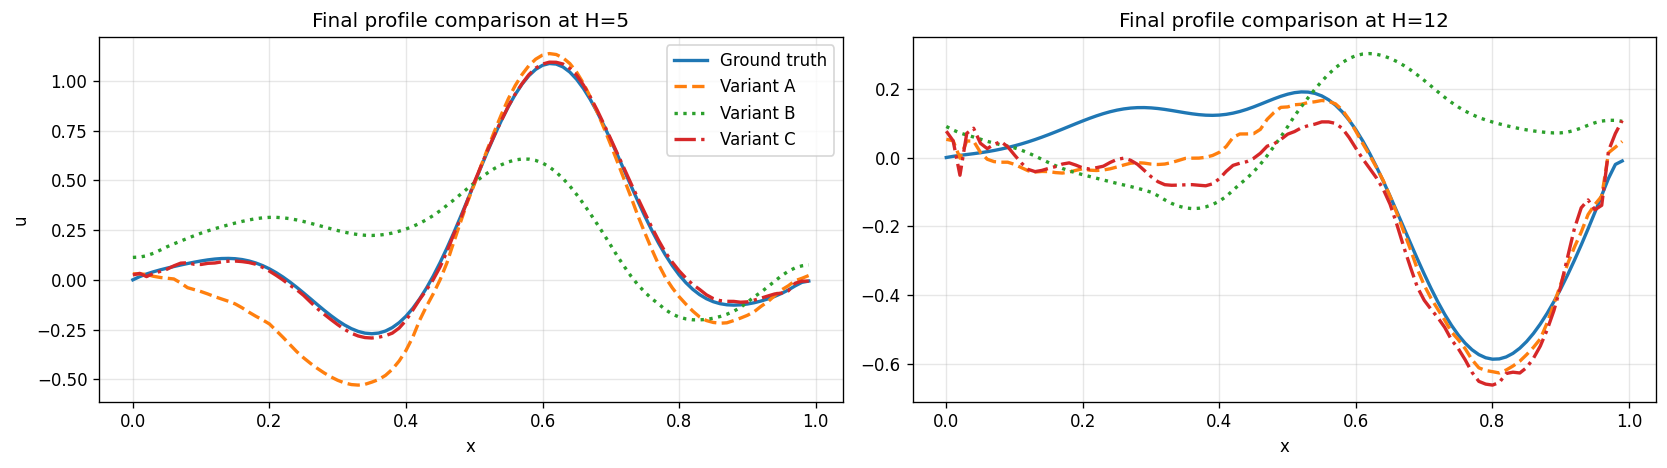

In [16]:
# 19) Single-trajectory rollout comparison across horizons H=5 and H=12 (Variants A/B/C)
# Native rolled axis: chunk index k (trajectory window steps), not chunk-internal time.
# Control alignment rule: use ctrl_seq[:, k] with current state u_k to predict u_{k+1}.

sample_id_cmp = 0
start_chunk_cmp = 0
horizons_cmp = [5, 12]

traj_sol_cmp = sol_test_chunks[sample_id_cmp]  # (n_chunks, chunk_len, nx, 1)
traj_ctrl_cmp = ctrl_test_chunks[sample_id_cmp]  # (n_chunks, chunk_len, n_ctrl, 1)

if traj_sol_cmp.shape[0] != traj_ctrl_cmp.shape[0]:
    raise ValueError(
        f"State/control chunk count mismatch: sol={traj_sol_cmp.shape[0]}, ctrl={traj_ctrl_cmp.shape[0]}"
    )

chunk_len_cmp = int(traj_sol_cmp.shape[1])
nx_cmp = int(traj_sol_cmp.shape[2])
n_ctrl_cmp = int(traj_ctrl_cmp.shape[2])

print("variant:", "gaussian_actuators")
print("context:", "checkpoint-eval")
print("traj_sol:", tuple(traj_sol_cmp.shape))
print("traj_ctrl:", tuple(traj_ctrl_cmp.shape))
print("n_intervals:", n_intervals)
print("chunk_len:", chunk_len_cmp, "nx:", nx_cmp, "n_ctrl:", n_ctrl_cmp)

model.eval()
ar_model.eval()

rows = []
plot_payload = {}

with torch.no_grad():
    for H_cmp in horizons_cmp:
        max_start_cmp = traj_sol_cmp.shape[0] - n_intervals - H_cmp
        if max_start_cmp < 0:
            raise ValueError(
                f"Not enough chunks for H={H_cmp}. Have n_chunks={traj_sol_cmp.shape[0]}, n_intervals={n_intervals}."
            )

        start_cmp = min(start_chunk_cmp, max_start_cmp)

        # History windows for warm-up Variant C.
        state_hist_chunks = traj_sol_cmp[
            start_cmp : start_cmp + n_intervals
        ]  # (T_hist, chunk_len, nx, 1)
        ctrl_hist_chunks = traj_ctrl_cmp[
            start_cmp : start_cmp + n_intervals
        ]  # (T_hist, chunk_len, n_ctrl, 1)

        x_state_hist_cmp = (
            state_hist_chunks.permute(0, 3, 1, 2).unsqueeze(0).to(device).float()
        )  # (1, T_hist, 1, chunk_len, nx)
        x_ctrl_hist_cmp = (
            ctrl_hist_chunks.permute(0, 3, 1, 2).unsqueeze(0).to(device).float()
        )  # (1, T_hist, 1, chunk_len, n_ctrl)

        u0_cmp = x_state_hist_cmp[:, -1]  # (1, 1, chunk_len, nx)

        ctrl_seq_chunks = traj_ctrl_cmp[
            start_cmp + n_intervals - 1 : start_cmp + n_intervals - 1 + H_cmp
        ]  # (H, chunk_len, n_ctrl, 1)
        ctrl_seq_cmp = (
            ctrl_seq_chunks.permute(0, 3, 1, 2).unsqueeze(0).to(device).float()
        )  # (1, H, 1, chunk_len, n_ctrl)

        y_true_chunks = traj_sol_cmp[
            start_cmp + n_intervals : start_cmp + n_intervals + H_cmp
        ]  # (H, chunk_len, nx, 1)

        assert x_state_hist_cmp.ndim == 5, x_state_hist_cmp.shape
        assert x_ctrl_hist_cmp.ndim == 5, x_ctrl_hist_cmp.shape
        assert ctrl_seq_cmp.ndim == 5, ctrl_seq_cmp.shape
        assert ctrl_seq_cmp.shape[1] == H_cmp, (ctrl_seq_cmp.shape, H_cmp)

        # Variant A: carry hidden states.
        pred_roll_A_cmp, _ = rollout_variant_a_carry(
            ar_model_obj=ar_model,
            u0=u0_cmp,
            ctrl_seq=ctrl_seq_cmp,
            steps=H_cmp,
        )  # (1, H+1, 1, chunk_len, nx)
        # Consistency check against wrapper rollout.
        pred_roll_A_cmp_ref = ar_model.rollout(
            u0=u0_cmp,
            ctrl_seq=ctrl_seq_cmp,
            steps=H_cmp,
        )
        assert torch.allclose(
            pred_roll_A_cmp, pred_roll_A_cmp_ref, atol=1e-6, rtol=1e-5
        ), f"Variant A helper mismatch vs ar_model.rollout for H={H_cmp}"

        # Variant B: reset hidden states at each step.
        pred_roll_B_cmp = rollout_variant_b_reset_each_step(
            ar_model_obj=ar_model,
            u0=u0_cmp,
            ctrl_seq=ctrl_seq_cmp,
            steps=H_cmp,
        )  # (1, H+1, 1, chunk_len, nx)

        # Variant C: warm-up on history then carry hidden states.
        pred_roll_C_cmp, warmup_steps_cmp, _ = rollout_variant_c_warmup_then_carry(
            ar_model_obj=ar_model,
            x_state_hist=x_state_hist_cmp,
            x_ctrl_hist=x_ctrl_hist_cmp,
            u0=u0_cmp,
            ctrl_seq=ctrl_seq_cmp,
            steps=H_cmp,
        )  # (1, H+1, 1, chunk_len, nx)

        assert torch.isfinite(pred_roll_A_cmp).all(), (
            f"Variant A non-finite for H={H_cmp}"
        )
        assert torch.isfinite(pred_roll_B_cmp).all(), (
            f"Variant B non-finite for H={H_cmp}"
        )
        assert torch.isfinite(pred_roll_C_cmp).all(), (
            f"Variant C non-finite for H={H_cmp}"
        )

        pred_chunks_A = (
            pred_roll_A_cmp[0, 1:].permute(0, 2, 3, 1).detach().cpu()
        )  # (H, chunk_len, nx, 1)
        pred_chunks_B = (
            pred_roll_B_cmp[0, 1:].permute(0, 2, 3, 1).detach().cpu()
        )  # (H, chunk_len, nx, 1)
        pred_chunks_C = (
            pred_roll_C_cmp[0, 1:].permute(0, 2, 3, 1).detach().cpu()
        )  # (H, chunk_len, nx, 1)
        true_chunks = y_true_chunks.detach().cpu()  # (H, chunk_len, nx, 1)

        assert pred_chunks_A.shape == true_chunks.shape
        assert pred_chunks_B.shape == true_chunks.shape
        assert pred_chunks_C.shape == true_chunks.shape

        # Full rollout metrics (all H*chunk_len points).
        pred_flat_A = pred_chunks_A.squeeze(-1).reshape(H_cmp * chunk_len_cmp, nx_cmp)
        pred_flat_B = pred_chunks_B.squeeze(-1).reshape(H_cmp * chunk_len_cmp, nx_cmp)
        pred_flat_C = pred_chunks_C.squeeze(-1).reshape(H_cmp * chunk_len_cmp, nx_cmp)
        true_flat = true_chunks.squeeze(-1).reshape(H_cmp * chunk_len_cmp, nx_cmp)

        mse_A = torch.mean((pred_flat_A - true_flat) ** 2).item()
        mse_B = torch.mean((pred_flat_B - true_flat) ** 2).item()
        mse_C = torch.mean((pred_flat_C - true_flat) ** 2).item()

        rel_A = (
            torch.linalg.norm(pred_flat_A - true_flat)
            / (torch.linalg.norm(true_flat) + 1e-12)
        ).item()
        rel_B = (
            torch.linalg.norm(pred_flat_B - true_flat)
            / (torch.linalg.norm(true_flat) + 1e-12)
        ).item()
        rel_C = (
            torch.linalg.norm(pred_flat_C - true_flat)
            / (torch.linalg.norm(true_flat) + 1e-12)
        ).item()

        # Endpoint metrics at step H.
        y_end_A = pred_roll_A_cmp[:, -1]  # (1, 1, chunk_len, nx)
        y_end_B = pred_roll_B_cmp[:, -1]  # (1, 1, chunk_len, nx)
        y_end_C = pred_roll_C_cmp[:, -1]  # (1, 1, chunk_len, nx)
        y_end_true = (
            y_true_chunks[-1].permute(2, 0, 1).unsqueeze(0).to(y_end_A.device).float()
        )  # (1, 1, chunk_len, nx)

        end_rel_A = (
            (
                torch.linalg.norm((y_end_A - y_end_true).reshape(1, -1), dim=1)
                / (torch.linalg.norm(y_end_true.reshape(1, -1), dim=1) + 1e-12)
            )
            .mean()
            .item()
        )
        end_rel_B = (
            (
                torch.linalg.norm((y_end_B - y_end_true).reshape(1, -1), dim=1)
                / (torch.linalg.norm(y_end_true.reshape(1, -1), dim=1) + 1e-12)
            )
            .mean()
            .item()
        )
        end_rel_C = (
            (
                torch.linalg.norm((y_end_C - y_end_true).reshape(1, -1), dim=1)
                / (torch.linalg.norm(y_end_true.reshape(1, -1), dim=1) + 1e-12)
            )
            .mean()
            .item()
        )

        rows.append(
            {
                "H": H_cmp,
                "warmup_steps": int(warmup_steps_cmp),
                "mse_A": mse_A,
                "mse_B": mse_B,
                "mse_C": mse_C,
                "rel_A": rel_A,
                "rel_B": rel_B,
                "rel_C": rel_C,
                "end_rel_A": end_rel_A,
                "end_rel_B": end_rel_B,
                "end_rel_C": end_rel_C,
                "shape_pred_roll": tuple(pred_roll_A_cmp.shape),
                "shape_true": tuple(true_chunks.shape),
            }
        )

        plot_payload[H_cmp] = {
            "x": x_cord.squeeze().cpu().numpy(),
            "true_final": true_flat[-1].numpy(),
            "pred_final_A": pred_flat_A[-1].numpy(),
            "pred_final_B": pred_flat_B[-1].numpy(),
            "pred_final_C": pred_flat_C[-1].numpy(),
        }

print("Rollout comparison summary (single trajectory):")
print("H | warmup | rollout_shape | true_shape")
for r in rows:
    print(
        f"{r['H']:>2d} | {r['warmup_steps']:>6d} | {r['shape_pred_roll']} | {r['shape_true']}"
    )

print("Relative L2 over full rollout (all predicted chunks):")
for r in rows:
    print(
        f"H={r['H']:>2d} | A={r['rel_A']:.6e} | B={r['rel_B']:.6e} | C={r['rel_C']:.6e} "
        # f"| (B-A)={r['rel_B'] - r['rel_A']:+.3e} | (C-A)={r['rel_C'] - r['rel_A']:+.3e} | (C-B)={r['rel_C'] - r['rel_B']:+.3e}"
    )

print("Endpoint Relative L2 at final step (k=H):")
for r in rows:
    print(
        f"H={r['H']:>2d} | A={r['end_rel_A']:.6e} | B={r['end_rel_B']:.6e} | C={r['end_rel_C']:.6e} "
        # f"| (B-A)={r['end_rel_B'] - r['end_rel_A']:+.3e} | (C-A)={r['end_rel_C'] - r['end_rel_A']:+.3e} | (C-B)={r['end_rel_C'] - r['end_rel_B']:+.3e}"
    )

# Final-profile overlays (one panel per horizon).
fig, axes = plt.subplots(
    1, len(horizons_cmp), figsize=(7 * len(horizons_cmp), 4), dpi=120
)
if len(horizons_cmp) == 1:
    axes = [axes]

for ax, H_cmp in zip(axes, horizons_cmp):
    pp = plot_payload[H_cmp]
    ax.plot(
        pp["x"], pp["true_final"], label="Ground truth", color="#1f77b4", linewidth=2
    )
    ax.plot(
        pp["x"],
        pp["pred_final_A"],
        label="Variant A",
        color="#ff7f0e",
        linestyle="--",
        linewidth=2,
    )
    ax.plot(
        pp["x"],
        pp["pred_final_B"],
        label="Variant B",
        color="#2ca02c",
        linestyle=":",
        linewidth=2,
    )
    ax.plot(
        pp["x"],
        pp["pred_final_C"],
        label="Variant C",
        color="#d62728",
        linestyle="-.",
        linewidth=2,
    )
    ax.set_title(f"Final profile comparison at H={H_cmp}")
    ax.set_xlabel("x")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("u")
axes[0].legend(loc="best")
plt.tight_layout()
plt.show()


In [ ]:
# 20) Utility check: endpoint evaluation across Variants A/B/C
# Confirms reusable rno_functions utility works with loaded checkpoint and current data windows.

try:
    from rno_functions import evaluate_endpoint_metrics_variants
except ModuleNotFoundError:
    from heat.rno_functions import evaluate_endpoint_metrics_variants

H_train = int(fine_tuning_num_steps)

if (
    "eval_steps" in globals()
    and isinstance(eval_steps, (list, tuple))
    and len(eval_steps) > 0
):
    eval_steps_var = [int(h) for h in eval_steps]
else:
    eval_steps_var = sorted(set([1, 2, 4, H_train, 8, 12]))

if "multi_step_test_eval_loaders" in globals() and isinstance(
    multi_step_test_eval_loaders, dict
):
    eval_loaders_var = dict(multi_step_test_eval_loaders)
else:
    eval_loaders_var = {}

# Ensure requested horizons are available in local evaluation loaders.
for h in eval_steps_var:
    if h in eval_loaders_var:
        continue

    if h not in multi_step_test_data:
        x_state_te, x_ctrl_hist_te, x_ctrl_seq_te, y_te = (
            build_state_control_windows_horizon(
                sol_test_chunks,
                ctrl_test_chunks,
                n_intervals,
                h,
            )
        )
        if x_state_te.shape[0] == 0:
            raise ValueError(
                f"No samples available for horizon h={h}. Dataset does not provide enough future steps/controls."
            )
        multi_step_test_data[h] = (x_state_te, x_ctrl_hist_te, x_ctrl_seq_te, y_te)

    x_state_te, x_ctrl_hist_te, x_ctrl_seq_te, y_te = multi_step_test_data[h]
    eval_loaders_var[h] = DataLoader(
        torch.utils.data.TensorDataset(x_state_te, x_ctrl_hist_te, x_ctrl_seq_te, y_te),
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
    )

history_eval = (
    int(multi_step_history) if "multi_step_history" in globals() else int(n_intervals)
)
warmup_eval = (
    int(multi_step_warmup_steps)
    if "multi_step_warmup_steps" in globals()
    else int(history_eval - 1)
)

endpoint_eval_results_variants = evaluate_endpoint_metrics_variants(
    ar_model_obj=ar_model,
    eval_loaders_by_h=eval_loaders_var,
    eval_steps=eval_steps_var,
    device=device,
    h_train=H_train,
    history=history_eval,
    warmup_steps=warmup_eval,
    variants=("A", "B", "C"),
    dt=dt,  # your dataset dt
    timesteps_per_control_action=1.0,
    show_window_count=False,
)


print()
print("Variant utility run complete.")
print("history:", history_eval, "warmup_steps:", warmup_eval)
print("eval_steps:", eval_steps_var)


x_state_hist: (75, 5, 1, 16, 100)
x_ctrl_hist: (75, 5, 1, 16, 4)
ctrl_seq used: (75, 1, 1, 16, 4)
y_true endpoint: (75, 1, 16, 100)
y_pred A endpoint: (75, 1, 16, 100)
y_pred B endpoint: (75, 1, 16, 100)
y_pred C endpoint: (75, 1, 16, 100)
warmup_steps used (C): 4
Endpoint Rel. L2 by horizon and variant
------------------------------------------------------------------------------------------------
H(chunks)  ChunkLen  RawSteps  TraversedSteps  PhysicalTime  CtrlActs  RelL2-A  RelL2-B  RelL2-C
1          16        16        16.000          0.016000      16        6.790343e-01  6.790343e-01  1.192045e-02
2          16        32        32.000          0.032000      32        5.686857e-01  8.857947e-01  1.205016e-02
4          16        64        64.000          0.064000      64        5.414188e-01  9.704758e-01  1.377606e-02
5          16        80        80.000          0.080000      80        5.413651e-01  9.767425e-01  1.640874e-02
8          16        128       128.000         0.1280

Using random traj_idx_full=10 (num_test_traj=80) for Variants A/B/C
Variant A summary
-----------------
traj_idx: 10
start_chunk: 0
history (chunks): 5
chunk_len: 16
raw steps available in trajectory: 400
history raw steps used: 80
forecast raw steps predicted: 320
traversed steps (effective): 320.0
physical time: 0.32
rel_l2_full=3.198541e-01, endpoint_rel_l2=1.653290e+00, mse_full=4.136409e-02


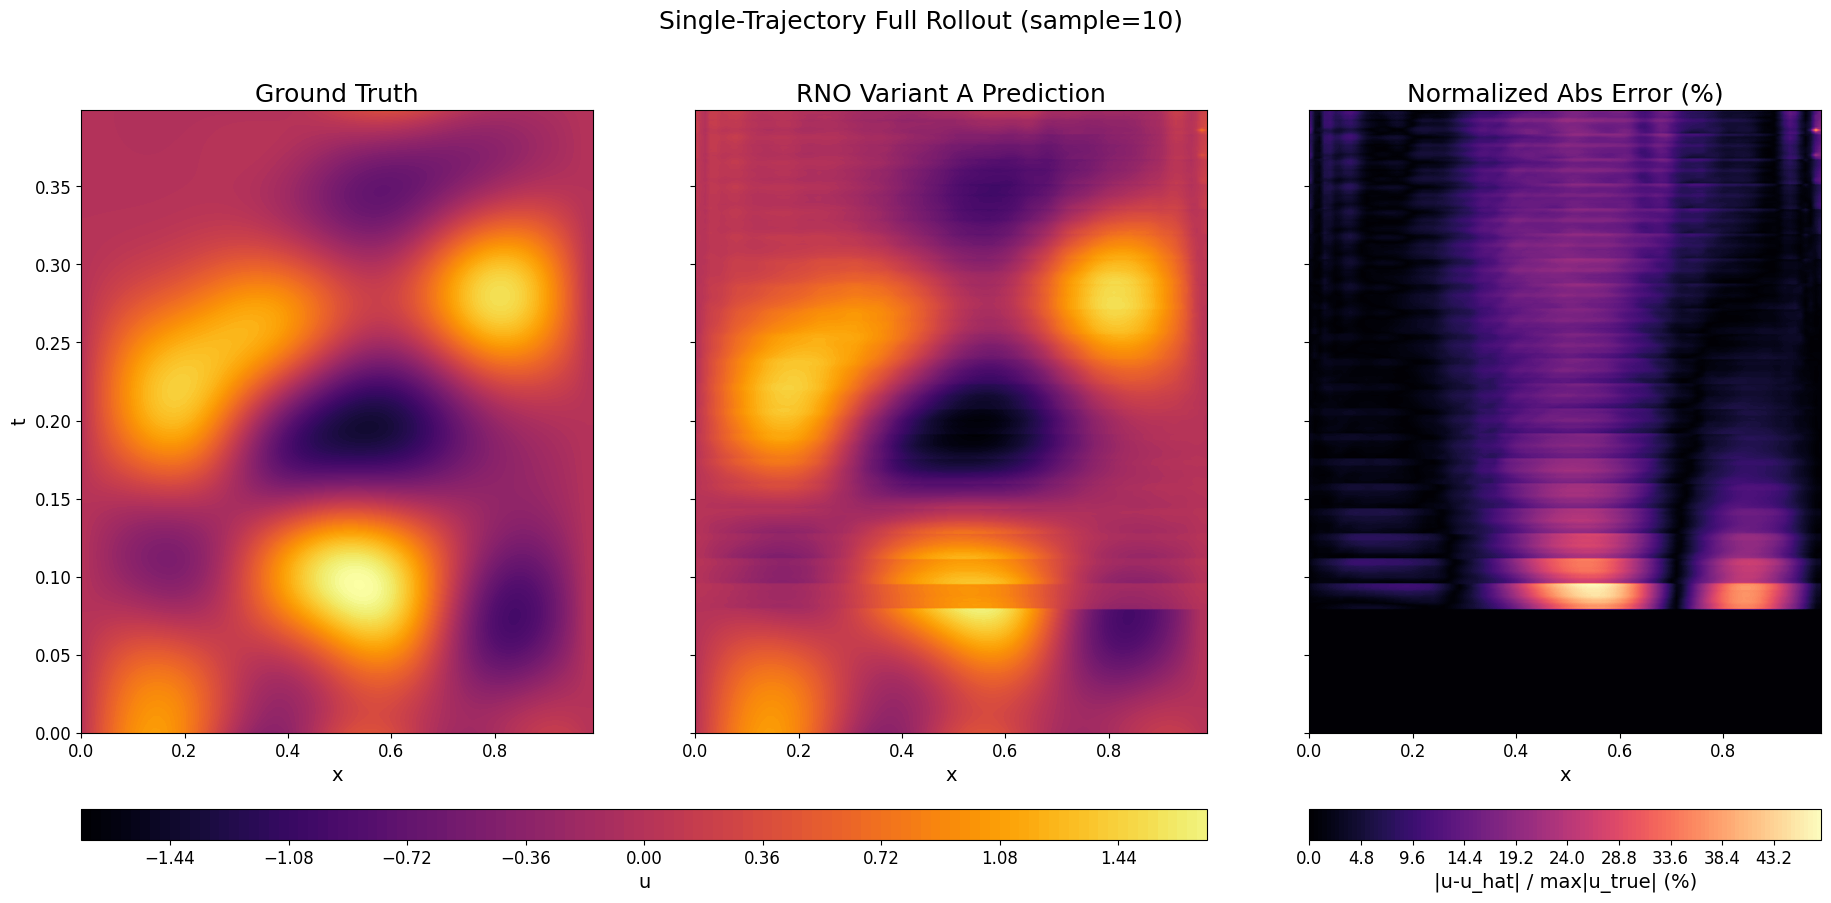

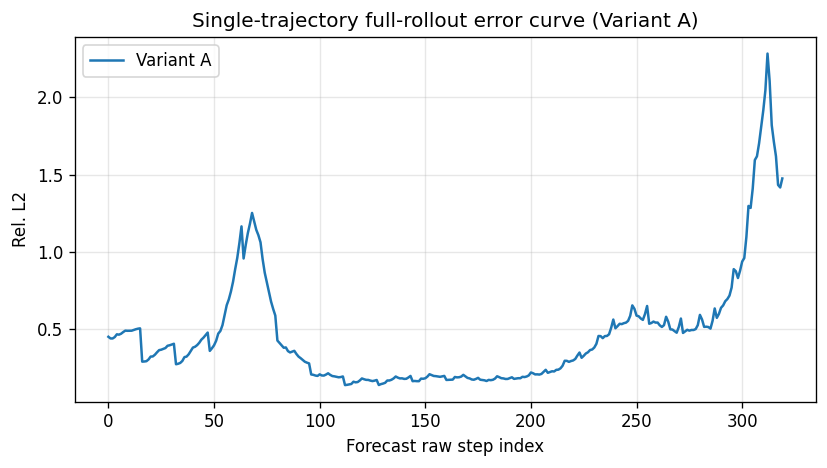

In [ ]:
# 21A) Single-trajectory full rollout (Variant A)
# Picks one random test trajectory index and reuses it for #21B/#21C.

try:
    from rno_functions import (
        evaluate_single_trajectory_full_rollout,
        plot_single_trajectory_rollout_contours,
    )
except ModuleNotFoundError:
    from heat.rno_functions import (
        evaluate_single_trajectory_full_rollout,
        plot_single_trajectory_rollout_contours,
    )

num_test_traj = int(sol_test_chunks.shape[0])
traj_idx_full = int(torch.randint(low=0, high=num_test_traj, size=(1,)).item())
start_chunk_full = 0
history_full = (
    int(multi_step_history) if "multi_step_history" in globals() else int(n_intervals)
)
warmup_full = (
    int(multi_step_warmup_steps)
    if "multi_step_warmup_steps" in globals()
    else max(history_full - 1, 0)
)

print(
    f"Using random traj_idx_full={traj_idx_full} (num_test_traj={num_test_traj}) for Variants A/B/C"
)

single_traj_full_results = {}
res_A = evaluate_single_trajectory_full_rollout(
    ar_model_obj=ar_model,
    sol_chunks=sol_test_chunks,
    ctrl_chunks=ctrl_test_chunks,
    traj_idx=traj_idx_full,
    start_chunk=start_chunk_full,
    history=history_full,
    variant="A",
    warmup_steps=warmup_full,
    device=device,
    dt=dt if "dt" in globals() else None,
    timesteps_per_control_action=1.0,
)
single_traj_full_results["A"] = res_A

raw_total_available = (
    int(sol_test.shape[1])
    if "sol_test" in globals()
    else int(res_A["true_full_raw"].shape[0])
)
history_raw_used = int(history_full * res_A["chunk_len"])
forecast_raw = int(res_A["raw_steps"])

print("Variant A summary")
print("-----------------")
print("traj_idx:", traj_idx_full)
print("start_chunk:", start_chunk_full)
print("history (chunks):", history_full)
print("chunk_len:", res_A["chunk_len"])
print("raw steps available in trajectory:", raw_total_available)
print("history raw steps used:", history_raw_used)
print("forecast raw steps predicted:", forecast_raw)
print("traversed steps (effective):", res_A["traversed_steps"])
print("physical time:", res_A["physical_time"])
print(
    f"rel_l2_full={res_A['metrics']['rel_l2_full']:.6e}, "
    f"endpoint_rel_l2={res_A['metrics']['endpoint_rel_l2']:.6e}, "
    f"mse_full={res_A['metrics']['mse_full']:.6e}"
)

if "dt" in globals():
    plot_single_trajectory_rollout_contours(
        true_states=res_A["true_full_raw"],
        rollout_pred=res_A["pred_full_raw"],
        x_cord=x_cord,
        dt_value=float(dt),
        sample_id_value=traj_idx_full,
        title_prefix="RNO Variant A",
    )
else:
    print("Skipping contour plot in #21A: dt is not defined.")

plt.figure(figsize=(7, 4), dpi=120)
plt.plot(res_A["raw_rel_l2_curve"].numpy(), label="Variant A")
plt.xlabel("Forecast raw step index")
plt.ylabel("Rel. L2")
plt.title("Single-trajectory full-rollout error curve (Variant A)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Variant B summary
-----------------
traj_idx: 10
rel_l2_full=7.507759e-01, endpoint_rel_l2=2.262138e+00, mse_full=2.278979e-01


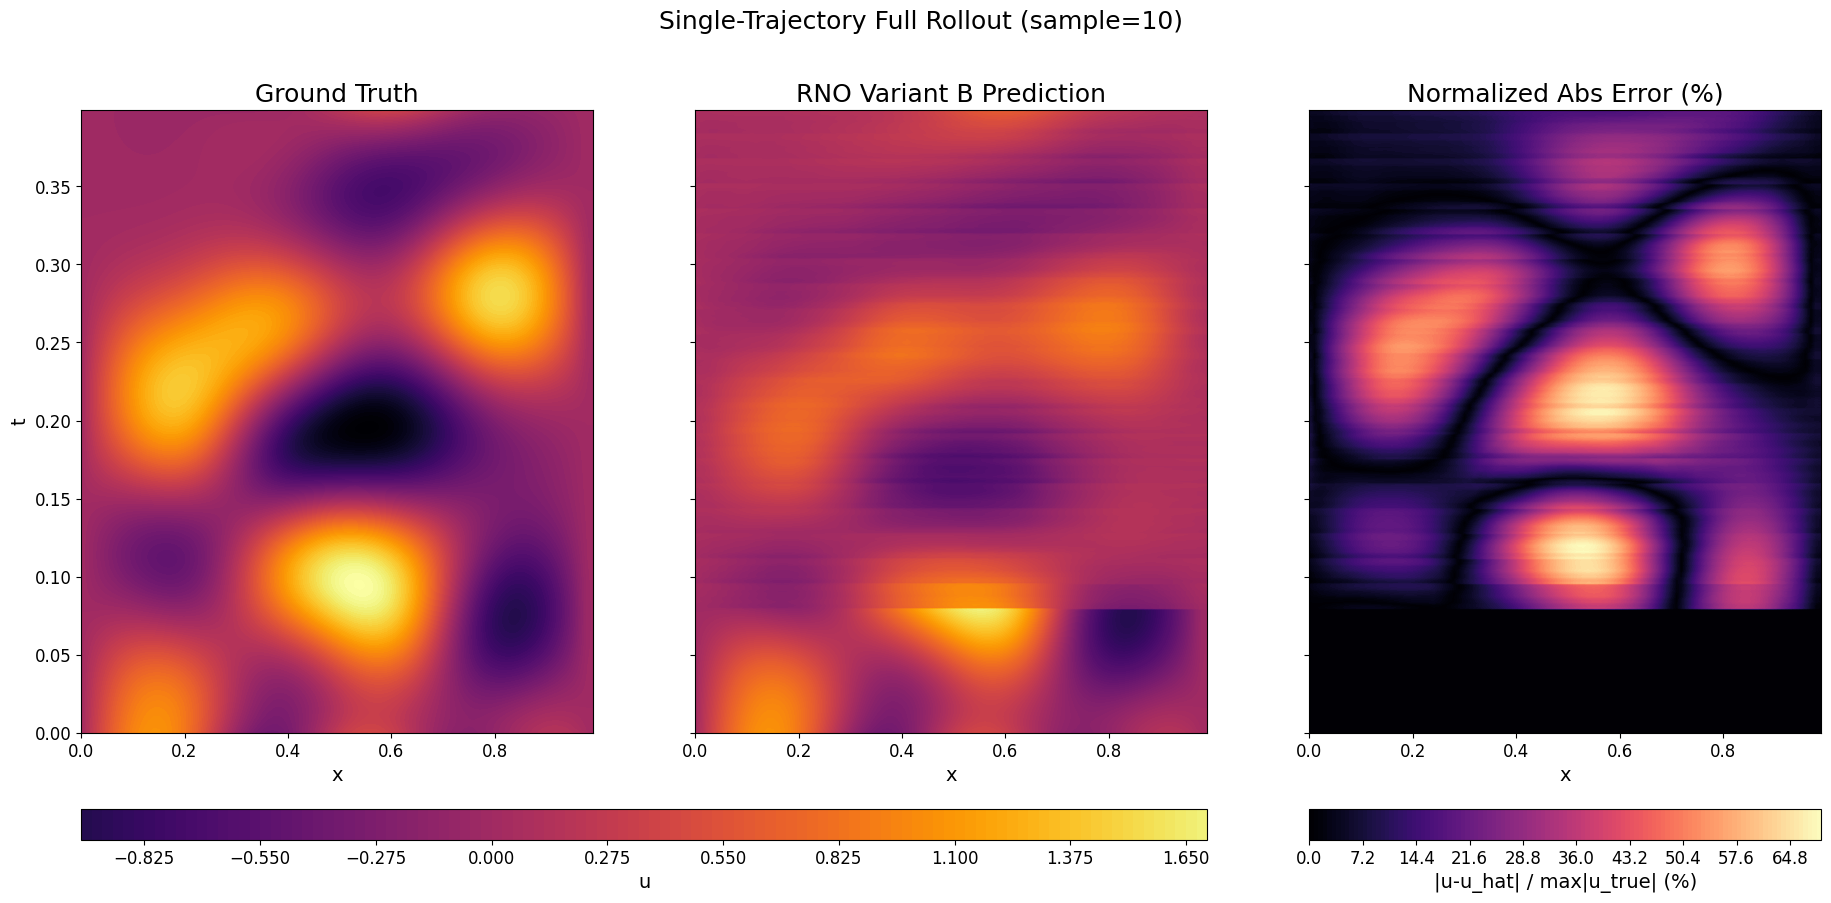

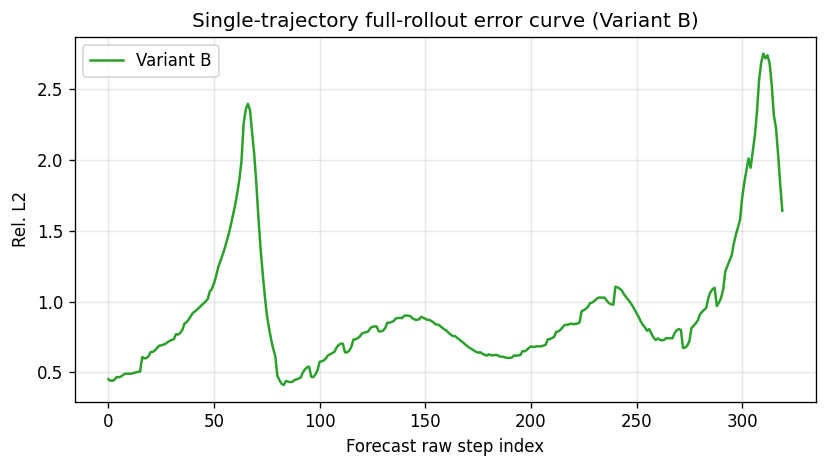

In [17]:
# 21B) Single-trajectory full rollout (Variant B)
# Reuses traj_idx_full selected in #21A.

try:
    from rno_functions import (
        evaluate_single_trajectory_full_rollout,
        plot_single_trajectory_rollout_contours,
    )
except ModuleNotFoundError:
    from heat.rno_functions import (
        evaluate_single_trajectory_full_rollout,
        plot_single_trajectory_rollout_contours,
    )

if "traj_idx_full" not in globals():
    raise ValueError("Run #21A first to initialize traj_idx_full.")

if "single_traj_full_results" not in globals():
    single_traj_full_results = {}

res_B = evaluate_single_trajectory_full_rollout(
    ar_model_obj=ar_model,
    sol_chunks=sol_test_chunks,
    ctrl_chunks=ctrl_test_chunks,
    traj_idx=traj_idx_full,
    start_chunk=start_chunk_full,
    history=history_full,
    variant="B",
    warmup_steps=warmup_full,
    device=device,
    dt=dt if "dt" in globals() else None,
    timesteps_per_control_action=1.0,
)
single_traj_full_results["B"] = res_B

print("Variant B summary")
print("-----------------")
print("traj_idx:", traj_idx_full)
print(
    f"rel_l2_full={res_B['metrics']['rel_l2_full']:.6e}, "
    f"endpoint_rel_l2={res_B['metrics']['endpoint_rel_l2']:.6e}, "
    f"mse_full={res_B['metrics']['mse_full']:.6e}"
)

if "dt" in globals():
    plot_single_trajectory_rollout_contours(
        true_states=res_B["true_full_raw"],
        rollout_pred=res_B["pred_full_raw"],
        x_cord=x_cord,
        dt_value=float(dt),
        sample_id_value=traj_idx_full,
        title_prefix="RNO Variant B",
    )
else:
    print("Skipping contour plot in #21B: dt is not defined.")

plt.figure(figsize=(7, 4), dpi=120)
plt.plot(res_B["raw_rel_l2_curve"].numpy(), label="Variant B", color="#2ca02c")
plt.xlabel("Forecast raw step index")
plt.ylabel("Rel. L2")
plt.title("Single-trajectory full-rollout error curve (Variant B)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Variant C summary
-----------------
traj_idx: 10
warmup_steps_used: 4
rel_l2_full=1.701418e-01, endpoint_rel_l2=2.093441e+00, mse_full=1.170420e-02


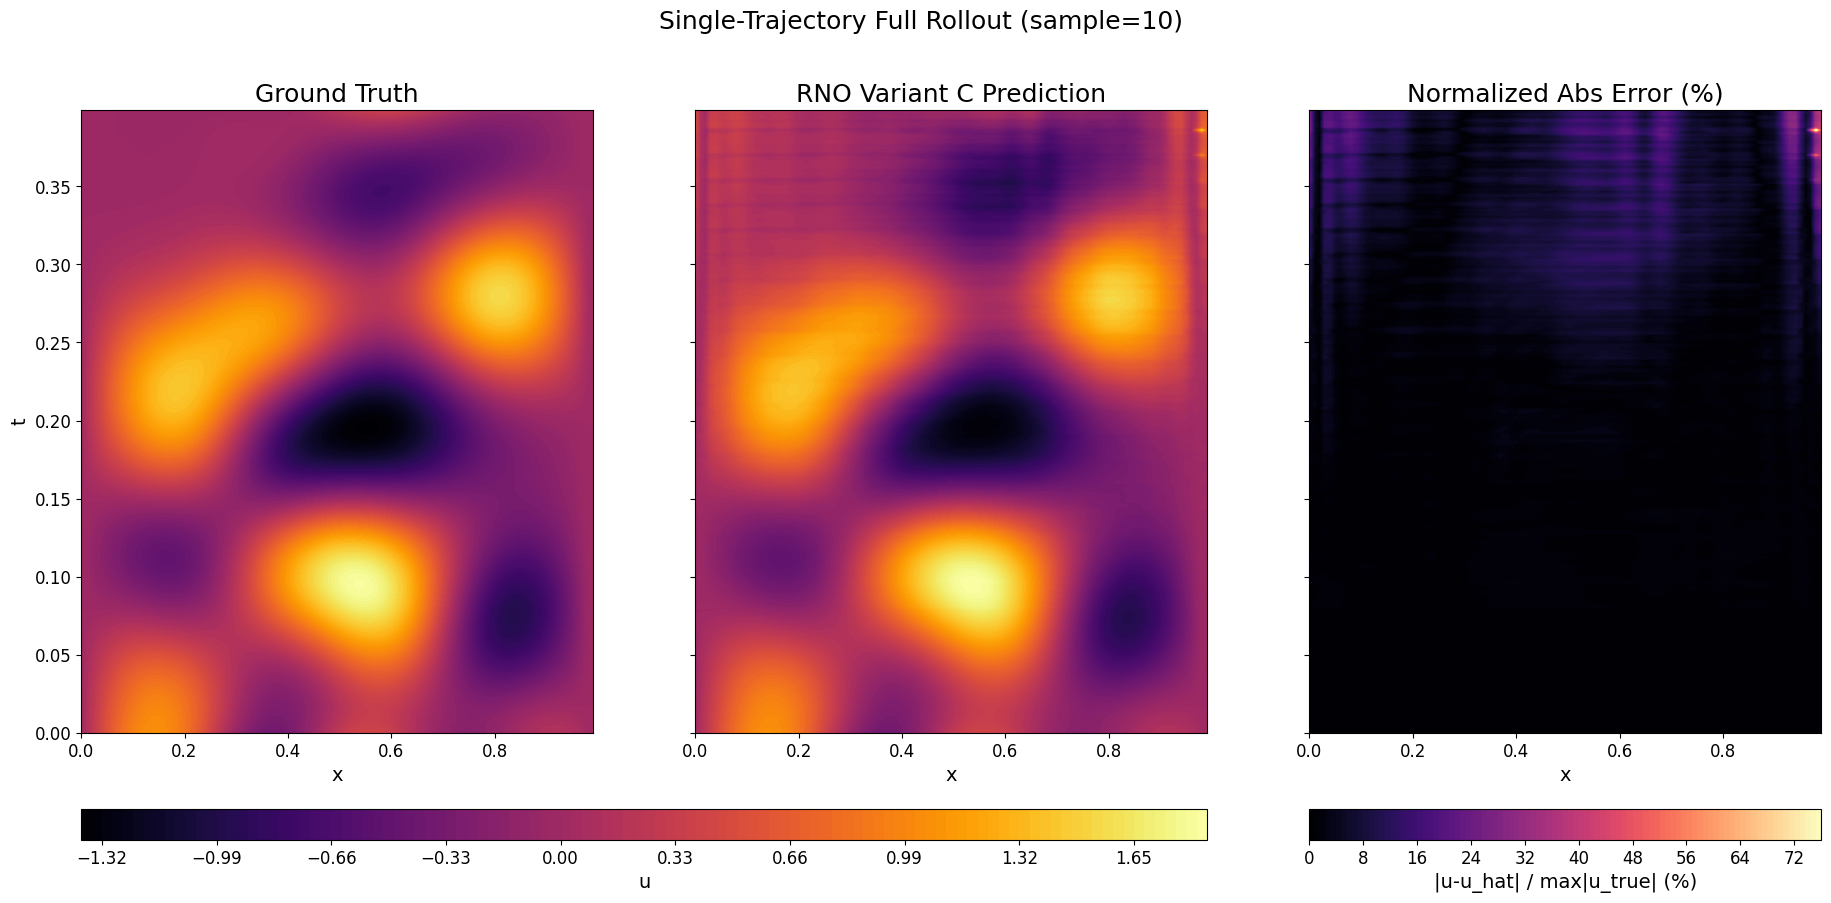

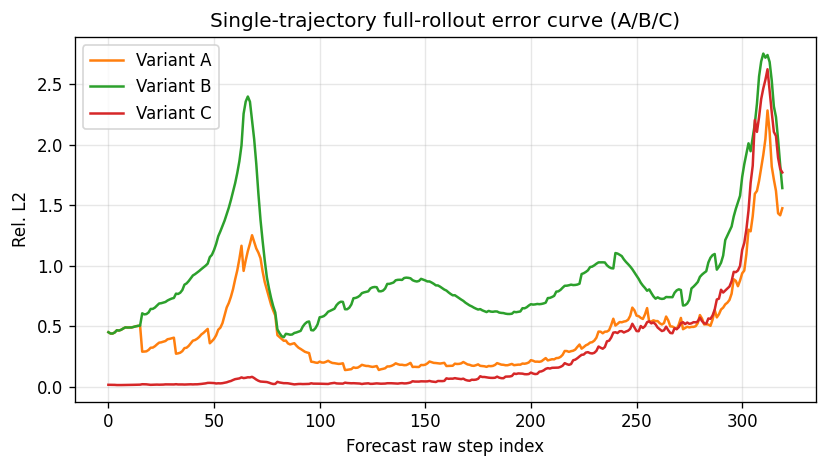

In [18]:
# 21C) Single-trajectory full rollout (Variant C)
# Reuses traj_idx_full selected in #21A.

try:
    from rno_functions import (
        evaluate_single_trajectory_full_rollout,
        plot_single_trajectory_rollout_contours,
    )
except ModuleNotFoundError:
    from heat.rno_functions import (
        evaluate_single_trajectory_full_rollout,
        plot_single_trajectory_rollout_contours,
    )

if "traj_idx_full" not in globals():
    raise ValueError("Run #21A first to initialize traj_idx_full.")

if "single_traj_full_results" not in globals():
    single_traj_full_results = {}

res_C = evaluate_single_trajectory_full_rollout(
    ar_model_obj=ar_model,
    sol_chunks=sol_test_chunks,
    ctrl_chunks=ctrl_test_chunks,
    traj_idx=traj_idx_full,
    start_chunk=start_chunk_full,
    history=history_full,
    variant="C",
    warmup_steps=warmup_full,
    device=device,
    dt=dt if "dt" in globals() else None,
    timesteps_per_control_action=1.0,
)
single_traj_full_results["C"] = res_C

print("Variant C summary")
print("-----------------")
print("traj_idx:", traj_idx_full)
print("warmup_steps_used:", res_C["warmup_steps_used"])
print(
    f"rel_l2_full={res_C['metrics']['rel_l2_full']:.6e}, "
    f"endpoint_rel_l2={res_C['metrics']['endpoint_rel_l2']:.6e}, "
    f"mse_full={res_C['metrics']['mse_full']:.6e}"
)

if "dt" in globals():
    plot_single_trajectory_rollout_contours(
        true_states=res_C["true_full_raw"],
        rollout_pred=res_C["pred_full_raw"],
        x_cord=x_cord,
        dt_value=float(dt),
        sample_id_value=traj_idx_full,
        title_prefix="RNO Variant C",
    )
else:
    print("Skipping contour plot in #21C: dt is not defined.")

# Overlay curves for all available variants on the same selected trajectory.
plt.figure(figsize=(7, 4), dpi=120)
for v, c in (("A", "#ff7f0e"), ("B", "#2ca02c"), ("C", "#d62728")):
    if v in single_traj_full_results:
        plt.plot(
            single_traj_full_results[v]["raw_rel_l2_curve"].numpy(),
            label=f"Variant {v}",
            color=c,
        )
plt.xlabel("Forecast raw step index")
plt.ylabel("Rel. L2")
plt.title("Single-trajectory full-rollout error curve (A/B/C)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
